,Unnamed: 0,Ligand_ID,ref_protein,ref_chain,mov_protein,mov_chain,cath_degree,ligand_rmsd,embedding_similarity,corr_rmsd,entropy,atom_type_fraction,radius_of_gyration
0,0,FUC,2nzy,C,2ygq,A,0,33.620255,2.599134,1.417954,0.687957,0.919216,1.594369
1,1,FE,6l3w,A,6rxn,A,0,0.953290,1.873158,1.560088,0.731882,0.410230,0.894852
2,2,FE2,1ey2,A,4oj8,B,0,1.451256,2.432473,1.476945,0.684184,0.791304,1.039891
3,3,SO3,1yt8,A,2vq2,A,0,16.152182,2.509382,1.678787,0.702045,0.935551,1.161084
4,4,BHO,2atj,A,2boy,A,0,10.576781,2.130411,1.532585,0.707347,0.876383,1.274134
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2308,2308,UDP,3hbn,A,7bv3,B,4,1.388283,4.022865,0.696391,0.787266,0.978165,0.790400
2309,2309,COA,1cm0,A,1yvk,A,4,4.076709,4.547650,0.588572,0.826497,0.971841,0.749466
2310,2310,FE,4ffk,A,8avl,A,4,0.050889,4.647954,0.337955,0.889899,0.999214,0.807387
2311,2311,FAD,2dki,A,5xhu,A,4,2.601060,4.701808,0.536026,0.856236,0.992549,0.702533


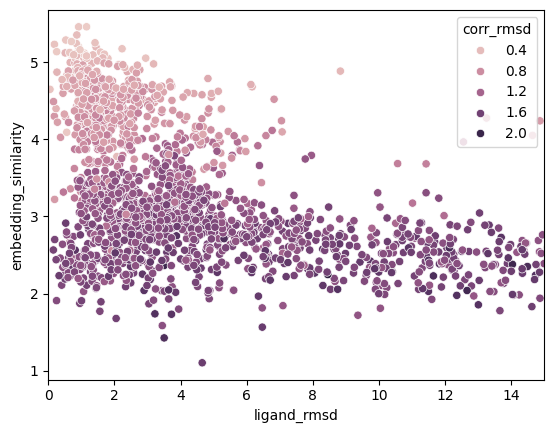

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt

table_results = 'per_sample_results_9-87099.csv'
checkpoint = 'baseline-embed01-ligand5-corr1-recycle4-radius05-sched-corr2/'

path2table = os.path.join('../plots/', table_results)
path2checkpoint = os.path.join('../checkpoints/',checkpoint)

table = pd.read_csv(path2table)

sns.scatterplot(data=table,x='ligand_rmsd',y='embedding_similarity',
                hue='corr_rmsd')
plt.xlim([0,15])
display(table)

In [8]:
from sklearn.model_selection import GroupKFold,GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer

table['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )
table['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )
table['radius_of_gyration_ang'] = table['radius_of_gyration'] * 1.3 * table['perplexity']**0.4

features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration_ang','perplexity']
monotonic_constraint = np.array([-1,1,1,-1])
target = 'ligand_rmsd'
target_cutoff = 10.


X = table[features]
y = table[target].map(lambda x: np.clip(x,0,target_cutoff))
groups = table['Ligand_ID'] # To avoid overfitting
stratify=table['cath_degree']==4. # To stratify by performance.

cross_val_split = GroupKFold(n_splits=5,shuffle=True,random_state=5)
cv_generator = cross_val_split.split(X=X, y=y, groups=groups)

regressor = HistGradientBoostingRegressor(loss='absolute_error',
                                          monotonic_cst=np.array([-1,1,1,-1])
                                          )


param_grid = {
    'l2_regularization': np.logspace(-2,0,num=5), # The smallest regularization is quite high to make sure that the prediction is smooth.
    'learning_rate': [0.025, 0.05,0.075,0.1],
    'max_iter': [50,100,200,300,400,500],
    'max_leaf_nodes': [7,15,31],
}


def spearman_scorer(y_true, y_pred):
    """
    Wraps scipy.stats.spearmanr to return only the correlation coefficient.
    """
    # spearmanr returns (correlation, pvalue)
    score, _ = spearmanr(y_true, y_pred)
    return score
# Create the scorer object
# greater_is_better=True because a higher correlation (closer to 1.0) is better
spearman_rank_scorer = make_scorer(spearman_scorer, greater_is_better=True)


grid_search = GridSearchCV(estimator=regressor,param_grid=param_grid,cv=cv_generator,scoring='neg_mean_absolute_error',
                           n_jobs=-1,refit=True)

grid_search.fit(X,y)

regressor = grid_search.best_estimator_


In [12]:
grid_search.best_params_

{'l2_regularization': 1.0,
 'learning_rate': 0.05,
 'max_iter': 200,
 'max_leaf_nodes': 15}

0.6751267364737762


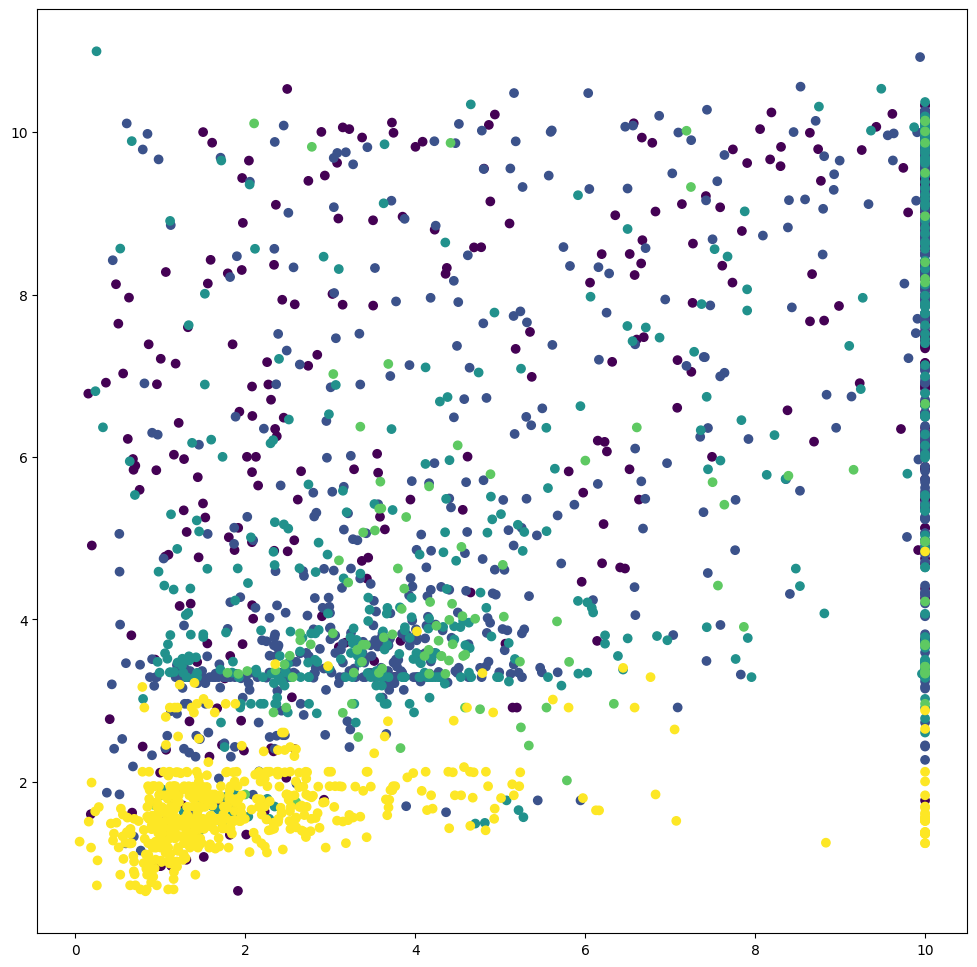

In [9]:
predictions = regressor.predict(X)
z = table['cath_degree']
fig, ax = plt.subplots(figsize=(12,12))
plt.scatter(y,predictions,c=z )
# sns.swarmplot(x=y_test,y=predictions,hue=z_test); 
print(np.corrcoef(y,predictions)[0,1])
plt.show()


0.6323346129319943


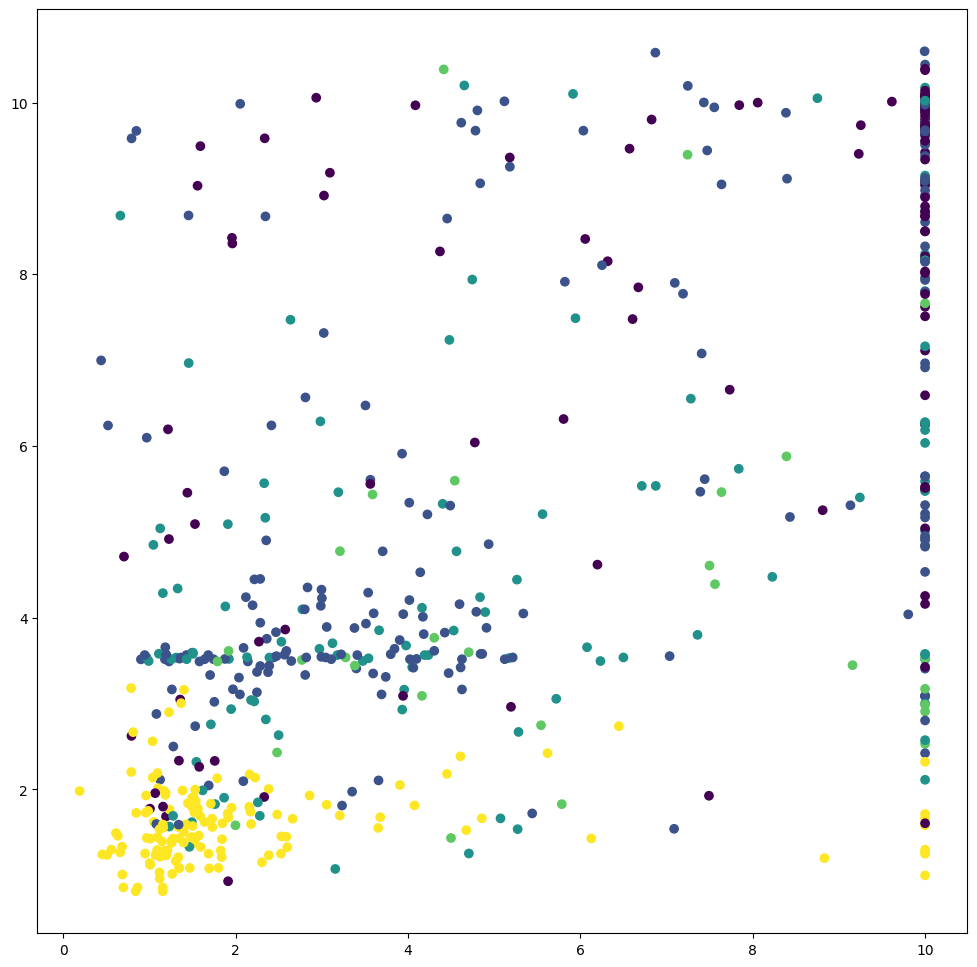

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

table['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )
table['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )
table['radius_of_gyration_ang'] = table['radius_of_gyration'] * 1.3 * table['perplexity']**0.4

features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration_ang','perplexity']
# features = ['embedding_similarity','corr_rmsd','radius_of_gyration','entropy']
# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']
# features = ['normalized_embedding_similarity','corr_rmsd','perplexity']

target = 'ligand_rmsd'

X = table[features]
y = table[target].map(lambda x: np.clip(x,0,10))

#thresholds = np.array([0.5, 1.,2.,4.])
# y = table[target].map( lambda x: (x>=thresholds).sum() )

z = table['cath_degree']
index = table['Unnamed: 0']

X_train,X_test,y_train,y_test,z_train,z_test,index_train,index_test = train_test_split(X,y,z,index)

regressor = HistGradientBoostingRegressor(loss='absolute_error',
                                          monotonic_cst=np.array([-1,1,1,-1])
                                          )


regressor.fit(X_train,y_train)

predictions = regressor.predict(X_test)

fig, ax = plt.subplots(figsize=(12,12))
plt.scatter(y_test,predictions,c=z_test )
# sns.swarmplot(x=y_test,y=predictions,hue=z_test); 
print(np.corrcoef(y_test,predictions)[0,1])
plt.show()


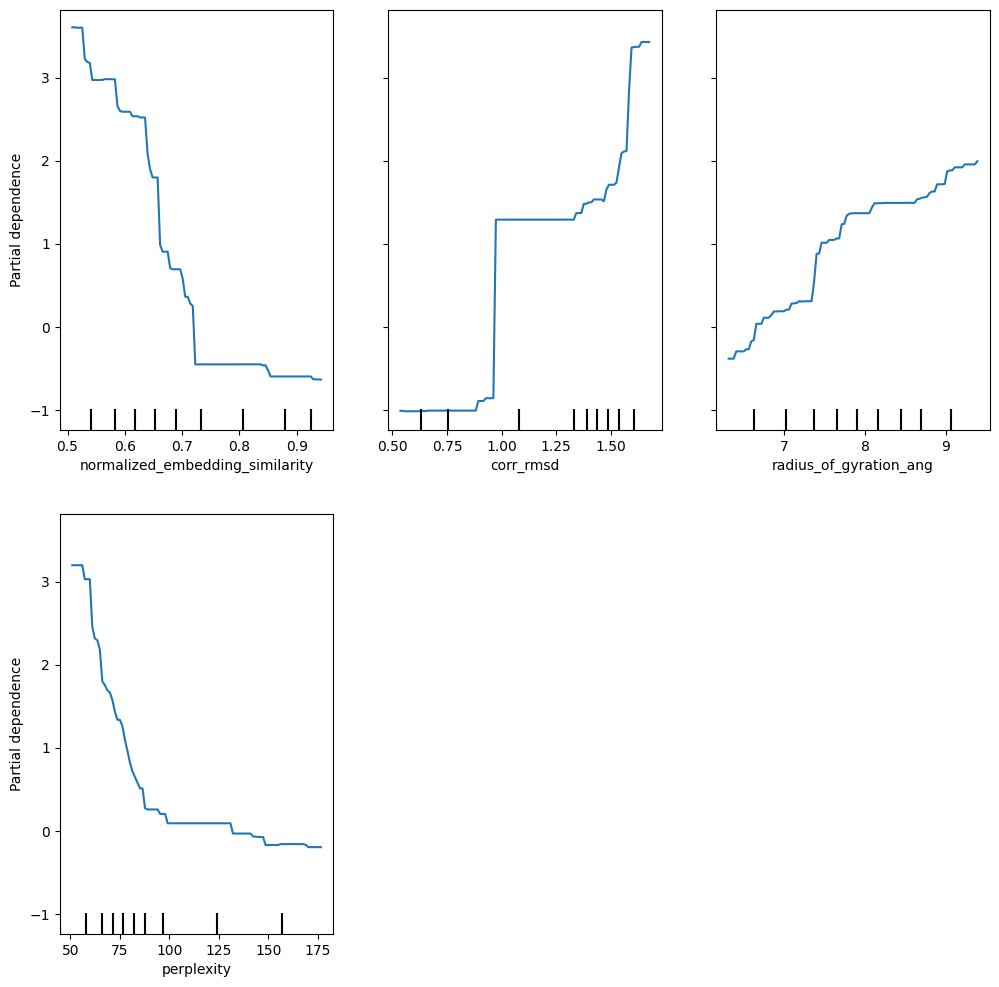

In [10]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax  = plt.subplots(figsize=(12,12))
display=PartialDependenceDisplay.from_estimator(regressor,X,features=features,ax=ax)
plt.show()

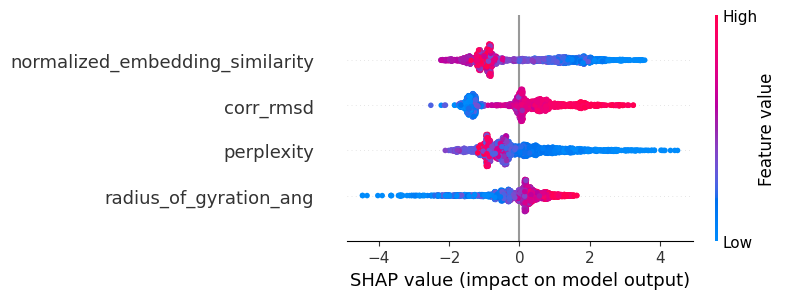

normalized_embedding_similarity,1.21
corr_rmsd,0.85
radius_of_gyration_ang,0.58
perplexity,0.85


In [11]:
import shap
explainer = shap.TreeExplainer(model=regressor)
shap_values = explainer.shap_values(X)
feature_importances = np.abs(shap_values).mean(0)
shap.summary_plot(shap_values, X, feature_names=features)

for feature,feature_importance in zip(features,feature_importances):
    print(f'{feature},{feature_importance:.2f}')

In [13]:
import pickle
pickle.dump(regressor, open(os.path.join(path2checkpoint,'calibration_model.pkl'),'wb') )

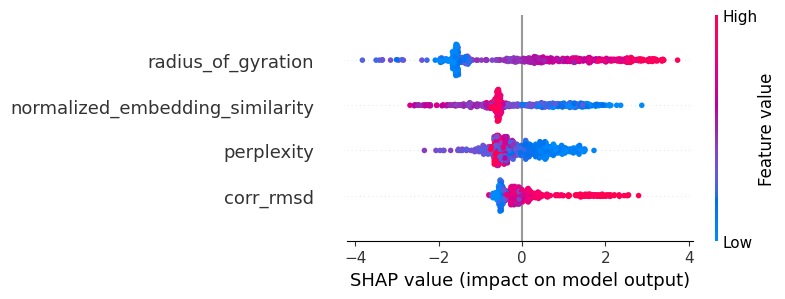

normalized_embedding_similarity,0.89
corr_rmsd,0.51
radius_of_gyration,1.45
perplexity,0.55


In [8]:
import shap
explainer = shap.TreeExplainer(model=regressor)
shap_values = explainer.shap_values(X_test)
feature_importances = np.abs(shap_values).mean(0)
shap.summary_plot(shap_values, X_test, feature_names=features)

for feature,feature_importance in zip(features,feature_importances):
    print(f'{feature},{feature_importance:.2f}')

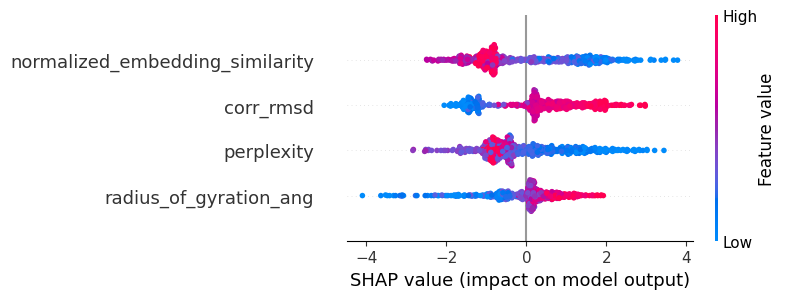

normalized_embedding_similarity,1.17
corr_rmsd,1.00
radius_of_gyration_ang,0.61
perplexity,0.88


In [6]:
import shap
explainer = shap.TreeExplainer(model=regressor)
shap_values = explainer.shap_values(X_test)
feature_importances = np.abs(shap_values).mean(0)
shap.summary_plot(shap_values, X_test, feature_names=features)

for feature,feature_importance in zip(features,feature_importances):
    print(f'{feature},{feature_importance:.2f}')


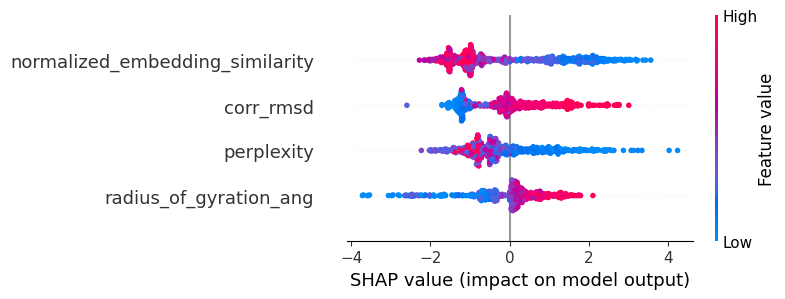

normalized_embedding_similarity,1.31
corr_rmsd,0.83
radius_of_gyration_ang,0.64
perplexity,0.81


In [10]:
import shap
explainer = shap.TreeExplainer(model=regressor)
shap_values = explainer.shap_values(X_test)
feature_importances = np.abs(shap_values).mean(0)
shap.summary_plot(shap_values, X_test, feature_names=features)

for feature,feature_importance in zip(features,feature_importances):
    print(f'{feature},{feature_importance:.2f}')

In [ ]:

order_predictions = np.argsort(predictions)
top_predictions = index_test.iloc[order_predictions]
top_table = table.iloc[top_predictions]
top_table_not_cath_4 = top_table[(top_table['cath_degree']<4) & (top_table['perplexity'] < 80)]
top_table_not_cath_4[:20]

# print( table.iloc[index_test[ (predictions<=1.75) & (z_test<4)]])


In [8]:

order_predictions = np.argsort(predictions)
top_predictions = index_test.iloc[order_predictions]
top_table = table.iloc[top_predictions]
top_table_bad = top_table[top_table['ligand_rmsd']>5]
top_table_bad



NameError: name 'index_test' is not defined

In [67]:
table.columns

Index(['Unnamed: 0', 'Ligand_ID', 'ref_protein', 'ref_chain', 'mov_protein',
       'mov_chain', 'cath_degree', 'ligand_rmsd', 'embedding_similarity',
       'corr_rmsd', 'entropy', 'atom_type_fraction', 'radius_of_gyration',
       'normalized_embedding_similarity', 'perplexity'],
      dtype='object')

cath_degree
0    0.167355
1    0.195775
2    0.208431
3    0.135135
4    0.815835
Name: Success, dtype: float64


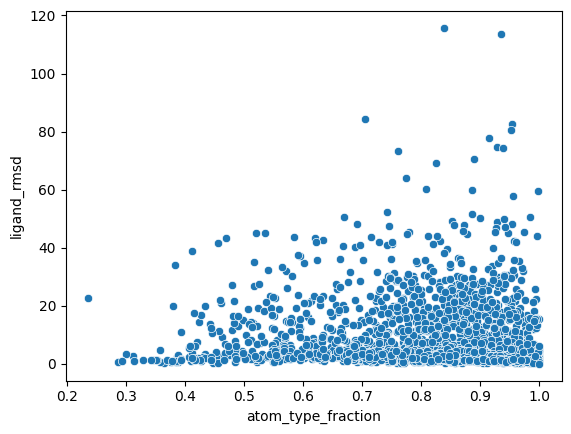

In [76]:
sns.scatterplot(table,x='atom_type_fraction',y='ligand_rmsd')

table['Success'] = (table['ligand_rmsd'] <= 3.0) & \
            (table['corr_rmsd'] <= 1.5) & \
                (table['atom_type_fraction'] >= 0.6)
                
print(table.groupby('cath_degree')['Success'].mean())
                    

In [104]:
list_entries = []

with open('/Users/jerometubiana/Downloads/protein_nr.fasta','r') as f:
    for line in f:
        if line.startswith('>'):
            list_entries.append( (line[1:5], line[5:-1]) )
            
print(list_entries)

print(list_entries[np.argmax([len(x[1]) for x in list_entries])] )



[('207l', 'A'), ('10mh', 'A'), ('11as', 'A'), ('11ba', 'A'), ('43ca', 'A'), ('43ca', 'B'), ('13pk', 'A'), ('351c', 'A'), ('155c', 'A'), ('25c8', 'H'), ('193l', 'A'), ('19hc', 'A'), ('1a05', 'A'), ('1a0a', 'A'), ('1a0c', 'A'), ('1a0d', 'A'), ('1a0e', 'A'), ('1a0g', 'B'), ('1a0h', 'B'), ('1a0i', 'A'), ('1a0j', 'A'), ('1a0l', 'A'), ('1a0r', 'B'), ('1a0s', 'P'), ('2a03', 'A'), ('2a06', 'D'), ('2a06', 'E'), ('2a07', 'J'), ('2a0b', 'A'), ('2a0f', 'A'), ('2a0s', 'A'), ('3a01', 'A'), ('3a01', 'F'), ('3a04', 'A'), ('3a06', 'B'), ('3a09', 'A'), ('3a0b', 'Z'), ('3a0b', 'E'), ('3a0b', 'L'), ('3a0b', 'M'), ('3a0b', 'V'), ('3a0d', 'A'), ('3a0h', 'T'), ('3a0t', 'A'), ('4a01', 'A'), ('4a04', 'B'), ('4a05', 'A'), ('4a0a', 'B'), ('4a0c', 'F'), ('4a0f', 'A'), ('4a0g', 'A'), ('4a0g', 'C'), ('4a0g', 'D'), ('4a0k', 'A'), ('4a0l', 'E'), ('4a0s', 'A'), ('4a0u', 'B'), ('5a01', 'A'), ('5a03', 'C'), ('5a07', 'A'), ('5a09', 'A'), ('5a0e', 'A'), ('5a0m', 'B'), ('5a0t', 'A'), ('5a0u', 'H'), ('5a0y', 'A'), ('5a0y', 